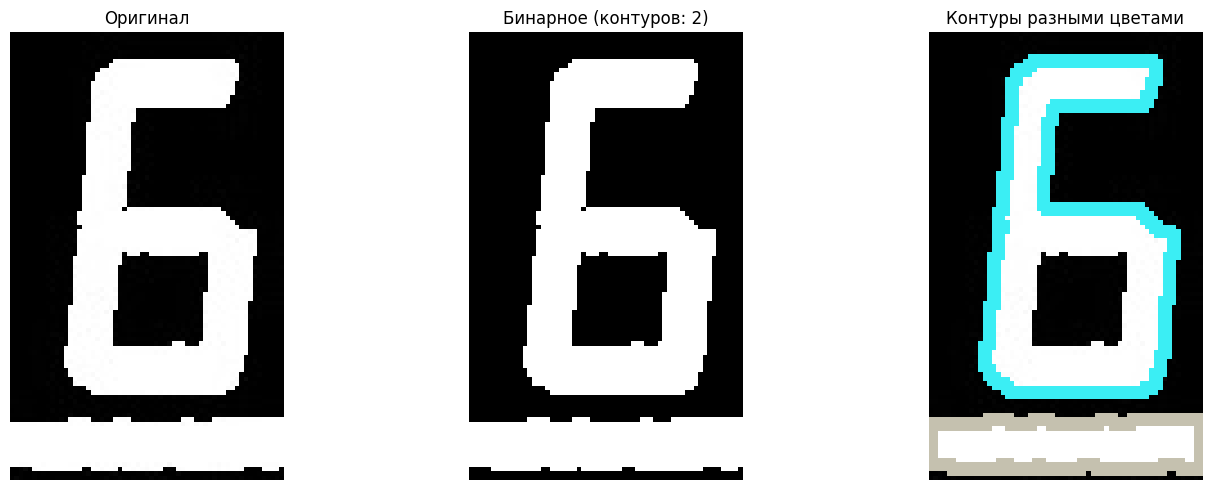

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

# Загружаем и бинаризуем
img = Image.open("/media/vadim/1TB_SSD/my_github/meter-watch/dataset_old/6/22510f74cd738a97cc5d499439922127201da451_2.jpg").convert('L')
# img = Image.open("/media/vadim/1TB_SSD/my_github/meter-watch/dataset_val/8/orgnl__0__0.56_9cf5c23b_23e530ee__aug.jpg").convert('L')
img_np = np.array(img)
# _, binary = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, binary = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Находим контуры
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Рисуем контуры разными цветами
debug_img = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)
for contour in contours:
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.drawContours(debug_img, [contour], -1, color, 2)

# Показываем
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Бинарное (контуров: {len(contours)})')
axes[1].axis('off')

axes[2].imshow(debug_img)
axes[2].set_title('Контуры разными цветами')
axes[2].axis('off')

plt.tight_layout()
plt.show()